In [1]:
!pip install mlcroissant -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.2 MB/s eta 0:00:00


In [2]:
import mlcroissant as mlc
import pandas as pd
import numpy as np

# Fetch the Croissant JSON-LD
dataset = mlc.Dataset('https://www.kaggle.com/datasets/menegidio/iris-species/croissant/download')

# Check what record sets are in the dataset
record_sets = dataset.metadata.record_sets
print(record_sets)

# Fetch the records and put them in a DataFrame
df = pd.DataFrame(dataset.records(record_set=record_sets[0].uuid))
df.head()

[RecordSet(uuid="Iris.csv")]


,Iris.csv/Id,Iris.csv/SepalLengthCm,Iris.csv/SepalWidthCm,Iris.csv/PetalLengthCm,Iris.csv/PetalWidthCm,Iris.csv/Species
0,b'1',5.1,3.5,1.4,0.2,b'Iris-setosa'
1,b'2',4.9,3.0,1.4,0.2,b'Iris-setosa'
2,b'3',4.7,3.2,1.3,0.2,b'Iris-setosa'
3,b'4',4.6,3.1,1.5,0.2,b'Iris-setosa'
4,b'5',5.0,3.6,1.4,0.2,b'Iris-setosa'


Correção dos nomes das colunas e das strings com 'b' como prefixo

In [3]:
df.columns = df.columns.str.replace('Iris.csv/','', regex = False)


for col in df.columns:
    if df[col].dtype == 'object':
        # Faz byte strings virarem strings normais
        df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

df['Id'] = pd.to_numeric(df['Id'])



EDA

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


None


Valores nulos por coluna:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


<Figure size 1000x800 with 0 Axes>

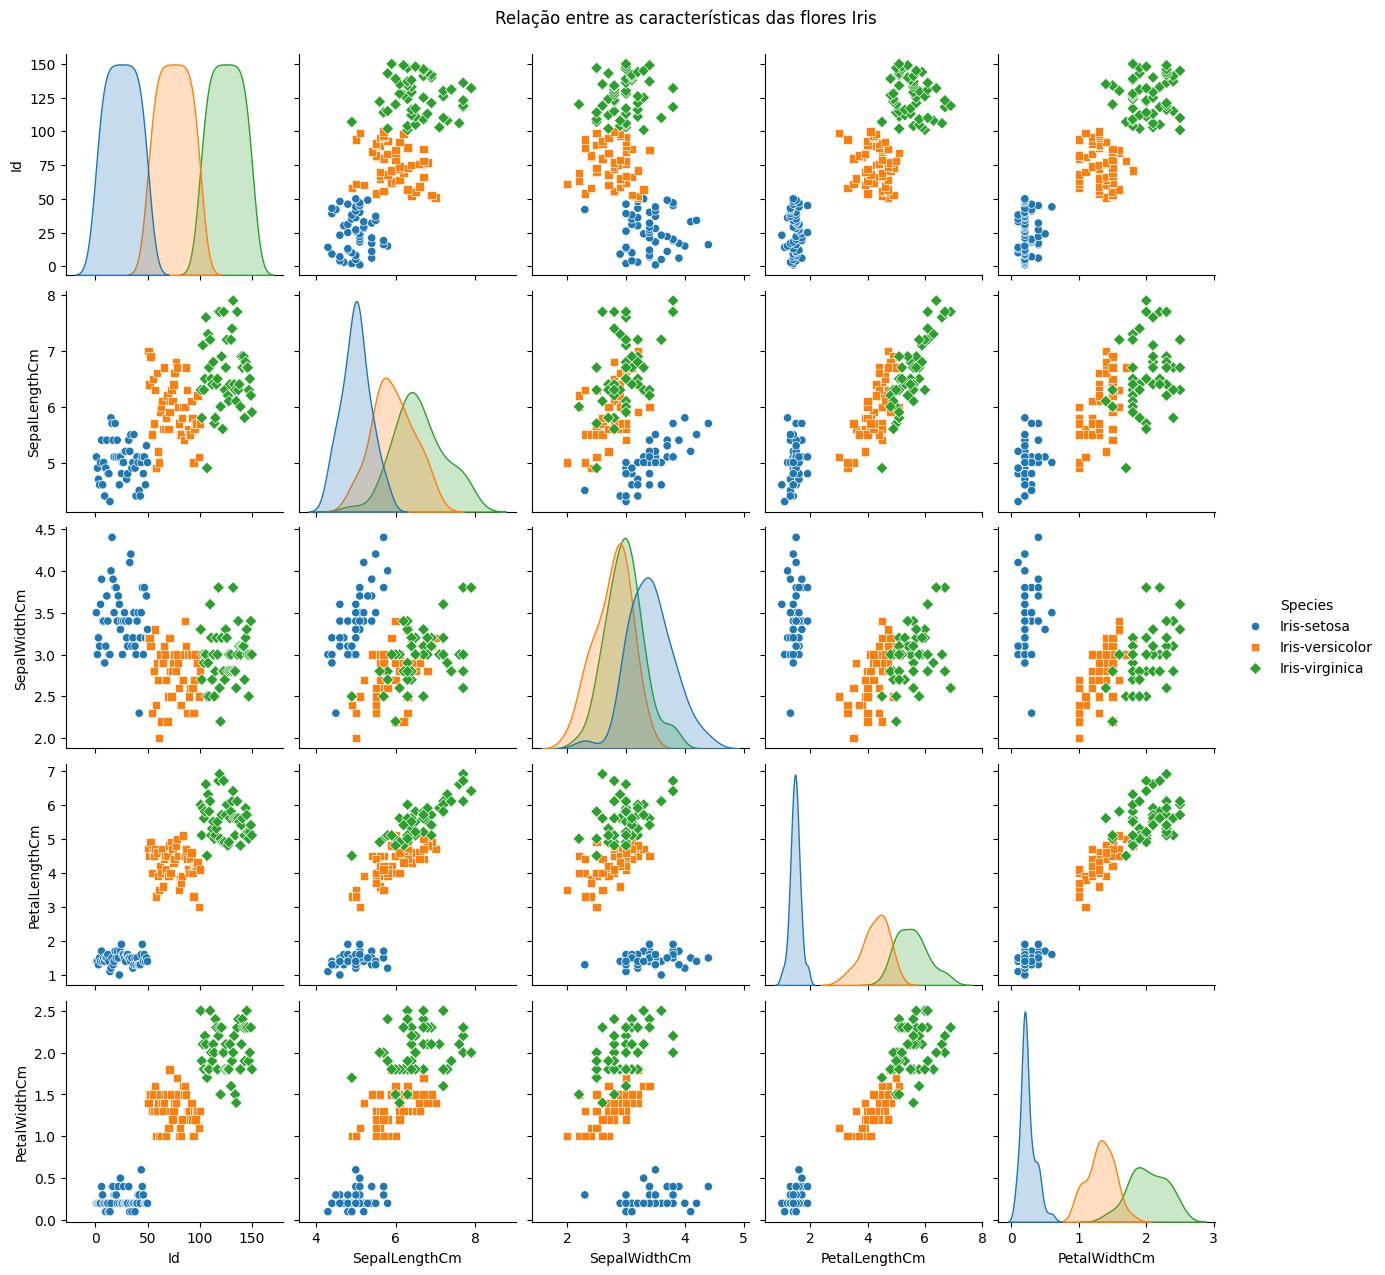

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
 
# Mostra as primeiras linhas
display(df.head())
display(df.info())
 
# Verificando se há valores nulos (dados faltantes)
print("\nValores nulos por coluna:")
print(df.isnull().sum())
 

 
# Visualização principal: Relação entre as variáveis
# O pairplot cria gráficos de dispersão para todas as combinações de features
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='Species', markers=["o", "s", "D"])
plt.suptitle("Relação entre as características das flores Iris", y=1.02)
plt.show()

In [5]:
# Bibliotecas para Machine Learning
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [6]:
# Features
X = df.drop(columns = ['Species', 'Id'])
y = df['Species']  # Os rótulos (labels)

# Dividindo em treino (80%) e teste (20%)
# O stratify=y garante que a proporção de espécies seja igual no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Criação e treinamento do modelo.

In [7]:
# Modelo usando kernerl linear
model = SVC(kernel = 'linear')

# Treinamento do modelo com os dados de treinamento
model.fit(X_train, y_train)

SVC(kernel='linear')

Previsões e avaliações do modelo

In [8]:
# Previsões
y_pred = model.predict(X_test)

# Acurácia(métrica)
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia do modelo: {accuracy * 100:.2f}%')

Acurácia do modelo: 100.00%


In [9]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [10]:
# Mostra a comparação do resultado predito e do real teste
print("Valores preditos:", y_pred)
print("Valores reais:", y_test)

Valores preditos: ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']
Valores reais: 38         Iris-setosa
127     Iris-virginica
57     Iris-versicolor
93     Iris-versicolor
42         Iris-setosa
56     Iris-versicolor
22         Iris-setosa
20         Iris-setosa
147     Iris-virginica
84     Iris-versicolor
107     Iris-virginica
141     Iris-virginica
104     Iris-virginica
51     Iris-versicolor
7          Iris-setosa
49         Iris-setosa
14         Iris-setosa
69     Iris-versicolor
63     Iris-versicolor
138     Iris-virginica
10      

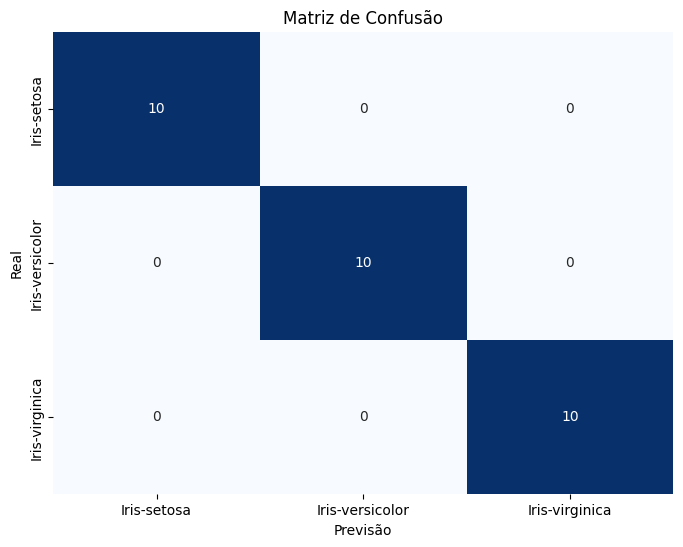

In [11]:
from sklearn.metrics import confusion_matrix

# Gera a matriz de confusão 'cm'
cm = confusion_matrix(y_test, y_pred)

# Faz um gráfico Heatmap baseado na matriz 'cm'
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()